# OrbitNet Benchmark Notebook
## Exact orbit validation and deflection-angle benchmark

This notebook evaluates the best retrained OrbitNet model for Schwarzschild photon orbits.

### Goals
1. Load the best checkpoint from the benchmarking sweep.
2. Summarize performance across experiments/seeds.
3. Validate the emulator against the analytic orbit solution $u(\phi)$.
4. Compare analytic and emulated trajectories in the orbital plane.
5. Compute the **deflection angle**:
   - from the **exact expression** in the paper,
   - from the **NN-emulated orbit**,
   - and compare against weak/strong-field approximations.

### Physical conventions
We use
$$
u(\phi) = \frac{R_S}{r(\phi)}.
$$
For scattering trajectories, the paper defines
$$
\delta\phi = \Delta\phi - \pi,
$$
where $\Delta\phi$ is the total angular change from infinity to infinity.

The exact expression used here is based on Eq. (56) of the paper.

In [1]:
import os
import sys
import time
import math
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from scipy.special import ellipk, ellipkinc

# ---------------------------------
# Plot style
# ---------------------------------
USE_DRACULA = True
if USE_DRACULA:
    import matplotx
    plt.style.use(matplotx.styles.dracula)

plt.rcParams.update({
    "figure.titlesize": 20,
    "axes.titlesize": 14,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 11,
    "lines.linewidth": 2.4,
})

# ---------------------------------
# Paths
# ---------------------------------
BASE = "/home/kingsman/Escritorio/PhD/PINN_paper/best_orbinet"
CODEDIR = os.path.join(BASE, "orbit_emulator")
RESULTS_CSV = os.path.join(BASE, "tables", "results.csv")
CKPT_DIR = os.path.join(BASE, "ckpt")

OUT_DIR = os.path.join(BASE, "out", "deflection_benchmark")
OUT_FIGS = os.path.join(OUT_DIR, "figs")
OUT_TAB = os.path.join(OUT_DIR, "tables")

os.makedirs(OUT_FIGS, exist_ok=True)
os.makedirs(OUT_TAB, exist_ok=True)

if CODEDIR not in sys.path:
    sys.path.insert(0, CODEDIR)

print("BASE      :", BASE)
print("CODEDIR   :", CODEDIR)
print("RESULTS   :", RESULTS_CSV)
print("CKPT_DIR  :", CKPT_DIR)
print("OUT_FIGS  :", OUT_FIGS)
print("OUT_TAB   :", OUT_TAB)

BASE      : /home/kingsman/Escritorio/PhD/PINN_paper/best_orbinet
CODEDIR   : /home/kingsman/Escritorio/PhD/PINN_paper/best_orbinet/orbit_emulator
RESULTS   : /home/kingsman/Escritorio/PhD/PINN_paper/best_orbinet/tables/results.csv
CKPT_DIR  : /home/kingsman/Escritorio/PhD/PINN_paper/best_orbinet/ckpt
OUT_FIGS  : /home/kingsman/Escritorio/PhD/PINN_paper/best_orbinet/out/deflection_benchmark/figs
OUT_TAB   : /home/kingsman/Escritorio/PhD/PINN_paper/best_orbinet/out/deflection_benchmark/tables


## Load benchmarking results and OrbitNet utilities

We load:
- the CSV with all experiment results,
- the checkpoint path for each experiment,
- and the core utilities from the local `orbit_emulator` package.

In [2]:
from orbit_emulator import (
    load_model_from_ckpt,
    bcrit,
    u_phi_general,
    predict_u,
)

df = pd.read_csv(RESULTS_CSV)

def local_ckpt(exp_id):
    return os.path.join(CKPT_DIR, f"best_{exp_id}.pt")

df["ckpt_path_local"] = df["exp_id"].apply(local_ckpt)
df["ckpt_exists"] = df["ckpt_path_local"].apply(os.path.exists)

print("Rows in results.csv:", len(df))
print("Rows with local ckpt:", df["ckpt_exists"].sum())

display(df.head())

Rows in results.csv: 3
Rows with local ckpt: 1


,exp_id,mode,target_transform,add_valid_flag,fill_value,N_traj,T,phi_max,K,seed,...,width,depth,best_epoch,best_val,test_mse,ckpt_path,dataset_path,seconds,ckpt_path_local,ckpt_exists
0,re27_seed150,filled,log1p,1,0.0,1800,1200,16.0,8,150,...,320,5,341,0.002608,0.002598,/scratch/jdrojas/orbit_emulator_runs/final_run...,/scratch/jdrojas/orbit_emulator_runs/datasets/...,3939.820516,/home/kingsman/Escritorio/PhD/PINN_paper/best_...,True
1,re27_seed151,filled,log1p,1,0.0,1800,1200,16.0,8,151,...,320,5,335,0.002874,0.002862,/scratch/jdrojas/orbit_emulator_runs/final_run...,/scratch/jdrojas/orbit_emulator_runs/datasets/...,3928.231267,/home/kingsman/Escritorio/PhD/PINN_paper/best_...,False
2,re27_seed152,filled,log1p,1,0.0,1800,1200,16.0,8,152,...,320,5,335,0.002894,0.002817,/scratch/jdrojas/orbit_emulator_runs/final_run...,/scratch/jdrojas/orbit_emulator_runs/datasets/...,3983.765011,/home/kingsman/Escritorio/PhD/PINN_paper/best_...,False


## Summary table of experiments

We sort experiments by test MSE and inspect the best available local checkpoints.

In [3]:
cols_show = [
    "exp_id", "seed", "mode", "target_transform", "add_valid_flag",
    "width", "depth", "K", "lambda_pinn", "best_val", "test_mse", "ckpt_exists"
]

ranked = df[df["ckpt_exists"]].sort_values("test_mse").reset_index(drop=True)
display(ranked[cols_show].head(15))

ranked[cols_show].head(15).to_csv(os.path.join(OUT_TAB, "top15_experiments.csv"), index=False)

,exp_id,seed,mode,target_transform,add_valid_flag,width,depth,K,lambda_pinn,best_val,test_mse,ckpt_exists
0,re27_seed150,150,filled,log1p,1,320,5,8,0.000001,0.002608,0.002598,True


## Aggregate metrics by hyperparameter setting

This groups repeated seeds for the same model configuration and computes mean/std.

In [4]:
group_cols = ["mode", "target_transform", "add_valid_flag", "width", "depth", "K", "lambda_pinn"]

agg = (
    df.groupby(group_cols, dropna=False)
      .agg(
          n_runs=("exp_id", "count"),
          best_val_mean=("best_val", "mean"),
          best_val_std=("best_val", "std"),
          test_mse_mean=("test_mse", "mean"),
          test_mse_std=("test_mse", "std"),
      )
      .reset_index()
      .sort_values("test_mse_mean")
      .reset_index(drop=True)
)

display(agg.head(10))
agg.to_csv(os.path.join(OUT_TAB, "aggregate_by_config.csv"), index=False)

,mode,target_transform,add_valid_flag,width,depth,K,lambda_pinn,n_runs,best_val_mean,best_val_std,test_mse_mean,test_mse_std
0,filled,log1p,1,320,5,8,0.000001,3,0.002792,0.000159,0.002759,0.000141


## Select the best model

We use the lowest-test-MSE checkpoint available locally.

In [6]:
best = ranked.iloc[0].copy()

exp_id = best["exp_id"]
ckpt_path = best["ckpt_path_local"]

print("Using best experiment:")
print(best[[
    "exp_id", "seed", "mode", "target_transform", "add_valid_flag",
    "width", "depth", "K", "lambda_pinn", "best_val", "test_mse"
]].to_string())

model, ckpt = load_model_from_ckpt(ckpt_path, map_location="cpu")
model.eval()

K = int(best.get("K", 8))
ADD_VALID_FLAG = bool(int(best.get("add_valid_flag", 1)))
TARGET_TF = str(best.get("target_transform", "log1p"))

Rs = 1.0
bc = bcrit(Rs)

print("\nDerived settings:")
print("Rs =", Rs)
print("b_crit =", bc)
print("K =", K)
print("ADD_VALID_FLAG =", ADD_VALID_FLAG)
print("TARGET_TF =", TARGET_TF)

Using best experiment:
exp_id              re27_seed150
seed                         150
mode                      filled
target_transform           log1p
add_valid_flag                 1
width                        320
depth                          5
K                              8
lambda_pinn             0.000001
best_val                0.002608
test_mse                0.002598

Derived settings:
Rs = 1.0
b_crit = 2.598076211353316
K = 8
ADD_VALID_FLAG = True
TARGET_TF = log1p


## Helper functions

This section defines:
- orbit-plane conversion,
- reference circles,
- benchmark cases,
- exact deflection angle from the paper,
- weak/strong-field approximations,
- and a numerical estimator of deflection angle from the emulated orbit.

In [8]:
# ----------------------------
# Pretty colors
# ----------------------------
C_ANALYTIC = "#ff79c6"
C_MODEL    = "#8be9fd"
C_HORIZON  = "#50fa7b"
C_PHOTON   = "#f1fa8c"
C_GRID     = "white"
C_EXACT    = "#ff79c6"
C_NN       = "#8be9fd"
C_WEAK     = "#50fa7b"
C_STRONG   = "#f1fa8c"

# ----------------------------
# Geometry helpers
# ----------------------------
def orbit_xy(phi, u, Rs=1.0):
    phi = np.asarray(phi, dtype=float)
    u = np.asarray(u, dtype=float)
    r = np.where(np.isfinite(u) & (u > 0), Rs / u, np.nan)
    x = r * np.cos(phi)
    y = r * np.sin(phi)
    return x, y, r

def draw_reference(ax, Rs=1.0):
    th = np.linspace(0, 2*np.pi, 900)
    ax.plot(Rs*np.cos(th), Rs*np.sin(th),
            ls=":", lw=2.0, color=C_HORIZON, alpha=0.95,
            label=r"Event horizon: $r=R_S$")
    ax.plot(1.5*Rs*np.cos(th), 1.5*Rs*np.sin(th),
            ls="--", lw=2.0, color=C_PHOTON, alpha=0.95,
            label=r"Photon sphere: $r=3R_S/2$")
    ax.scatter([0], [0], s=18, color="white", alpha=0.9)
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.18, color=C_GRID)

def make_cases(Rs=1.0):
    bc = bcrit(Rs)
    return [
        ("A_crit_out", bc, 2/3 + 0.12, dict(branch=None, region=None)),
        ("A_crit_in",  bc, 2/3 - 0.12, dict(branch=None, region=None)),
        ("B_incoming", 0.98*bc, 0.40, dict(branch="incoming", region=None)),
        ("B_outgoing", 0.98*bc, 0.90, dict(branch="outgoing", region=None)),
        ("C_scatter",  1.004*bc, 0.15, dict(branch=None, region="scatter")),
        ("C_inner",    1.004*bc, 0.92, dict(branch=None, region="inner")),
    ]

In [9]:
# ----------------------------
# Exact deflection formula (paper Eq. 56)
# ----------------------------
#
# For null Schwarzschild geodesics written in u = Rs/r,
# the turning-point cubic is:
#
#   u^3 - u^2 + (Rs/b)^2 = 0
#
# For scattering trajectories, the three real roots satisfy:
#   u1 < 0 < u2 < u3 < 1
#
# The exact angular change is:
#
#   Δφ = 4/sqrt(u3-u1) * [ K(k) - sn^{-1}( sqrt(-u1/(u2-u1)), k ) ]
#
# with
#   k^2 = (u2-u1)/(u3-u1)
#
# and δφ = Δφ - π.

def cubic_roots_u(Rs, b):
    coeff = [1.0, -1.0, 0.0, (Rs/b)**2]
    roots = np.roots(coeff)
    roots = np.real_if_close(roots, tol=1e5)

    if np.any(np.abs(np.imag(roots)) > 1e-10):
        return None

    roots = np.sort(np.real(roots))
    return roots  # [u1, u2, u3]

def deflection_exact_eq56(Rs, b):
    roots = cubic_roots_u(Rs, b)
    if roots is None:
        return np.nan, {}

    u1, u2, u3 = roots

    # Scattering condition
    if not (u1 < 0 < u2 < u3 < 1):
        return np.nan, {"u1": u1, "u2": u2, "u3": u3}

    m = (u2 - u1) / (u3 - u1)   # parameter m = k^2
    if not (0 <= m < 1):
        return np.nan, {"u1": u1, "u2": u2, "u3": u3, "m": m}

    z = np.sqrt((-u1) / (u2 - u1))
    z = np.clip(z, 0.0, 1.0)

    K_complete = ellipk(m)
    F_incomplete = ellipkinc(np.arcsin(z), m)

    Delta_phi = 4.0 / np.sqrt(u3 - u1) * (K_complete - F_incomplete)
    delta_phi = Delta_phi - np.pi

    aux = {
        "u1": u1,
        "u2": u2,
        "u3": u3,
        "m": m,
        "z": z,
        "Delta_phi": Delta_phi,
    }
    return delta_phi, aux

# ----------------------------
# Approximations from the paper
# ----------------------------
def deflection_weak_eq65(Rs, b):
    x = Rs / b
    return 2*x + (15*np.pi/16)*(x**2) + (16/3)*(x**3)

def deflection_strong_eq66(Rs, b):
    # Eq. (66) gives Delta_phi, then delta_phi = Delta_phi - pi
    denom = 1.0 - (3*np.sqrt(3)*Rs/(2*b))**2
    if denom <= 0:
        return np.nan
    Delta_phi = np.log(432*(2-np.sqrt(3))**2 / denom)
    return Delta_phi - np.pi

In [10]:
# ----------------------------
# Numerical deflection from an orbit u(phi)
# ----------------------------
#
# We estimate δφ from the emulated orbit by reading the two angular
# positions where the trajectory reaches a small asymptotic value u_eps.
#
# δφ ≈ φ_out - φ_in - π

def find_turning_index(u):
    u = np.asarray(u, float)
    m = np.isfinite(u) & (u > 0)
    if m.sum() < 5:
        return None
    idx_valid = np.where(m)[0]
    idx_local = np.argmax(u[m])
    return idx_valid[idx_local]

def interp_phi_at_u(phi_seg, u_seg, u_eps):
    phi_seg = np.asarray(phi_seg, float)
    u_seg   = np.asarray(u_seg, float)

    m = np.isfinite(phi_seg) & np.isfinite(u_seg) & (u_seg > 0)
    phi_seg = phi_seg[m]
    u_seg   = u_seg[m]

    if len(phi_seg) < 3:
        return np.nan

    keep = np.r_[True, np.diff(phi_seg) != 0]
    phi_seg = phi_seg[keep]
    u_seg = u_seg[keep]

    umin, umax = np.min(u_seg), np.max(u_seg)
    if not (umin <= u_eps <= umax):
        return np.nan

    order = np.argsort(u_seg)
    u_sorted = u_seg[order]
    phi_sorted = phi_seg[order]

    uu, idx = np.unique(u_sorted, return_index=True)
    pp = phi_sorted[idx]

    if len(uu) < 2:
        return np.nan

    return np.interp(u_eps, uu, pp)

def estimate_deflection_from_u(phi, u, u_eps=1e-3):
    phi = np.asarray(phi, float)
    u   = np.asarray(u, float)

    it = find_turning_index(u)
    if it is None or it <= 2 or it >= len(u)-3:
        return np.nan

    phi_in_seg = phi[:it+1]
    u_in_seg   = u[:it+1]

    phi_out_seg = phi[it:]
    u_out_seg   = u[it:]

    phi_in  = interp_phi_at_u(phi_in_seg, u_in_seg, u_eps)
    phi_out = interp_phi_at_u(phi_out_seg[::-1], u_out_seg[::-1], u_eps)

    if not np.isfinite(phi_in) or not np.isfinite(phi_out):
        return np.nan

    return phi_out - phi_in - np.pi

## Sanity check of the exact deflection formula

We test the exact expression and both approximations on a few scattering impact parameters.

In [11]:
b_test = np.linspace(1.01*bc, 1.20*bc, 6)

rows = []
for b in b_test:
    d_exact, aux = deflection_exact_eq56(Rs, b)
    d_weak = deflection_weak_eq65(Rs, b)
    d_strong = deflection_strong_eq66(Rs, b)
    rows.append({
        "b": b,
        "b/bc": b/bc,
        "delta_exact": d_exact,
        "delta_weak": d_weak,
        "delta_strong": d_strong,
    })

sanity_df = pd.DataFrame(rows)
display(sanity_df)

,b,b/bc,delta_exact,delta_weak,delta_strong
0,2.624057,1.010,4.229662,1.485088,4.219853
1,2.722784,1.048,2.732895,1.396037,2.706375
2,2.821511,1.086,2.210576,1.316242,2.176079
3,2.920238,1.124,1.899473,1.244409,1.860877
4,3.018965,1.162,1.682711,1.179461,1.642328
5,3.117691,1.200,1.519186,1.120503,1.478541


## Define the angular grid and benchmark cases

In [45]:
phi_max = 14.5
nphi = 4000
phi = np.linspace(1e-4, phi_max, nphi).astype(np.float32)

cases = make_cases(Rs)
cases

[('A_crit_out',
  2.598076211353316,
  0.7866666666666666,
  {'branch': None, 'region': None}),
 ('A_crit_in',
  2.598076211353316,
  0.5466666666666666,
  {'branch': None, 'region': None}),
 ('B_incoming',
  2.5461146871262494,
  0.4,
  {'branch': 'incoming', 'region': None}),
 ('B_outgoing',
  2.5461146871262494,
  0.9,
  {'branch': 'outgoing', 'region': None}),
 ('C_scatter',
  2.6084685161987293,
  0.15,
  {'branch': None, 'region': 'scatter'}),
 ('C_inner', 2.6084685161987293, 0.92, {'branch': None, 'region': 'inner'})]

## Qualitative validation: $u(\phi)$ and orbital-plane trajectories

We compare the analytic solution and OrbitNet prediction for representative orbit families.

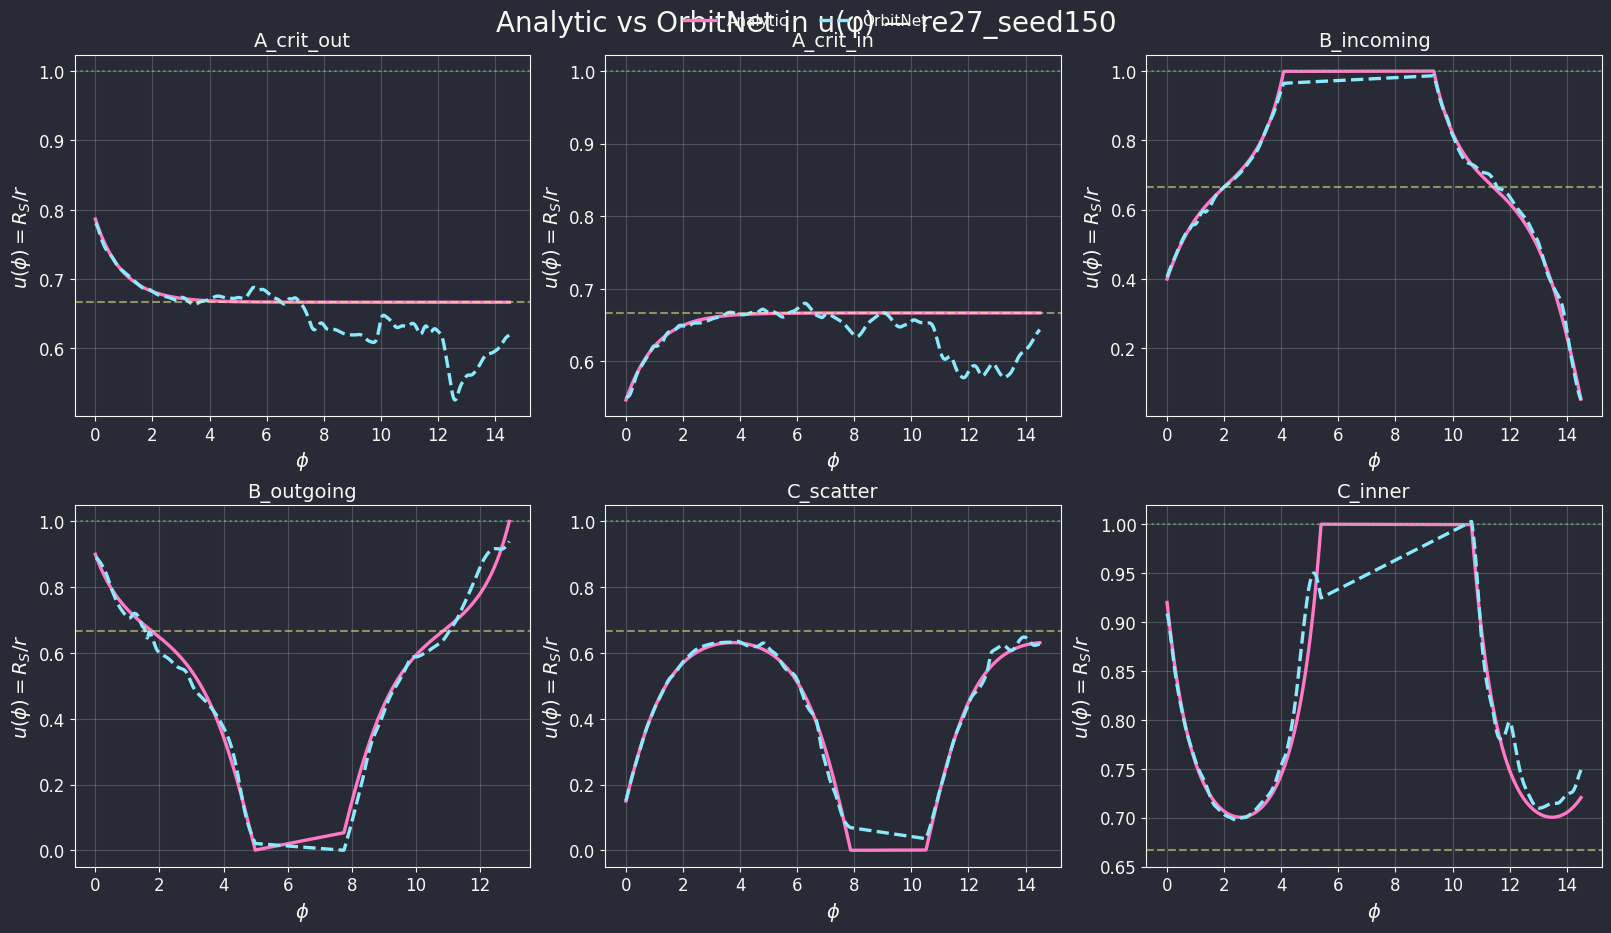

Saved: /home/kingsman/Escritorio/PhD/PINN_paper/best_orbinet/out/deflection_benchmark/figs/u_phi_grid_re27_seed150.png


In [46]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9), constrained_layout=True)
axes = axes.ravel()

for i, (name, b, u0, kwargs) in enumerate(cases):
    u_true, _ = u_phi_general(phi, Rs=Rs, b=b, u0=u0, phi0=0.0, **kwargs)
    u_hat = predict_u(
        model, phi, u0, b, Rs=Rs, K=K,
        add_valid_flag=ADD_VALID_FLAG,
        target_transform=TARGET_TF
    )

    m = np.isfinite(u_true) & (u_true > 0) & np.isfinite(u_hat) & (u_hat > 0)

    ax = axes[i]
    ax.plot(phi[m], u_true[m], color=C_ANALYTIC, label="Analytic")
    ax.plot(phi[m], u_hat[m], "--", color=C_MODEL, label="OrbitNet")
    ax.axhline(2/3, ls="--", lw=1.5, color=C_PHOTON, alpha=0.5)
    ax.axhline(1.0, ls=":", lw=1.5, color=C_HORIZON, alpha=0.5)
    ax.set_title(name)
    ax.set_xlabel(r"$\phi$")
    ax.set_ylabel(r"$u(\phi)=R_S/r$")
    ax.grid(True, alpha=0.18, color=C_GRID)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False)
fig.suptitle(f"Analytic vs OrbitNet in u(φ) — {exp_id}", y=1.02)

out = os.path.join(OUT_FIGS, f"u_phi_grid_{exp_id}.png")
fig.savefig(out, dpi=220, bbox_inches="tight")
plt.show()

print("Saved:", out)

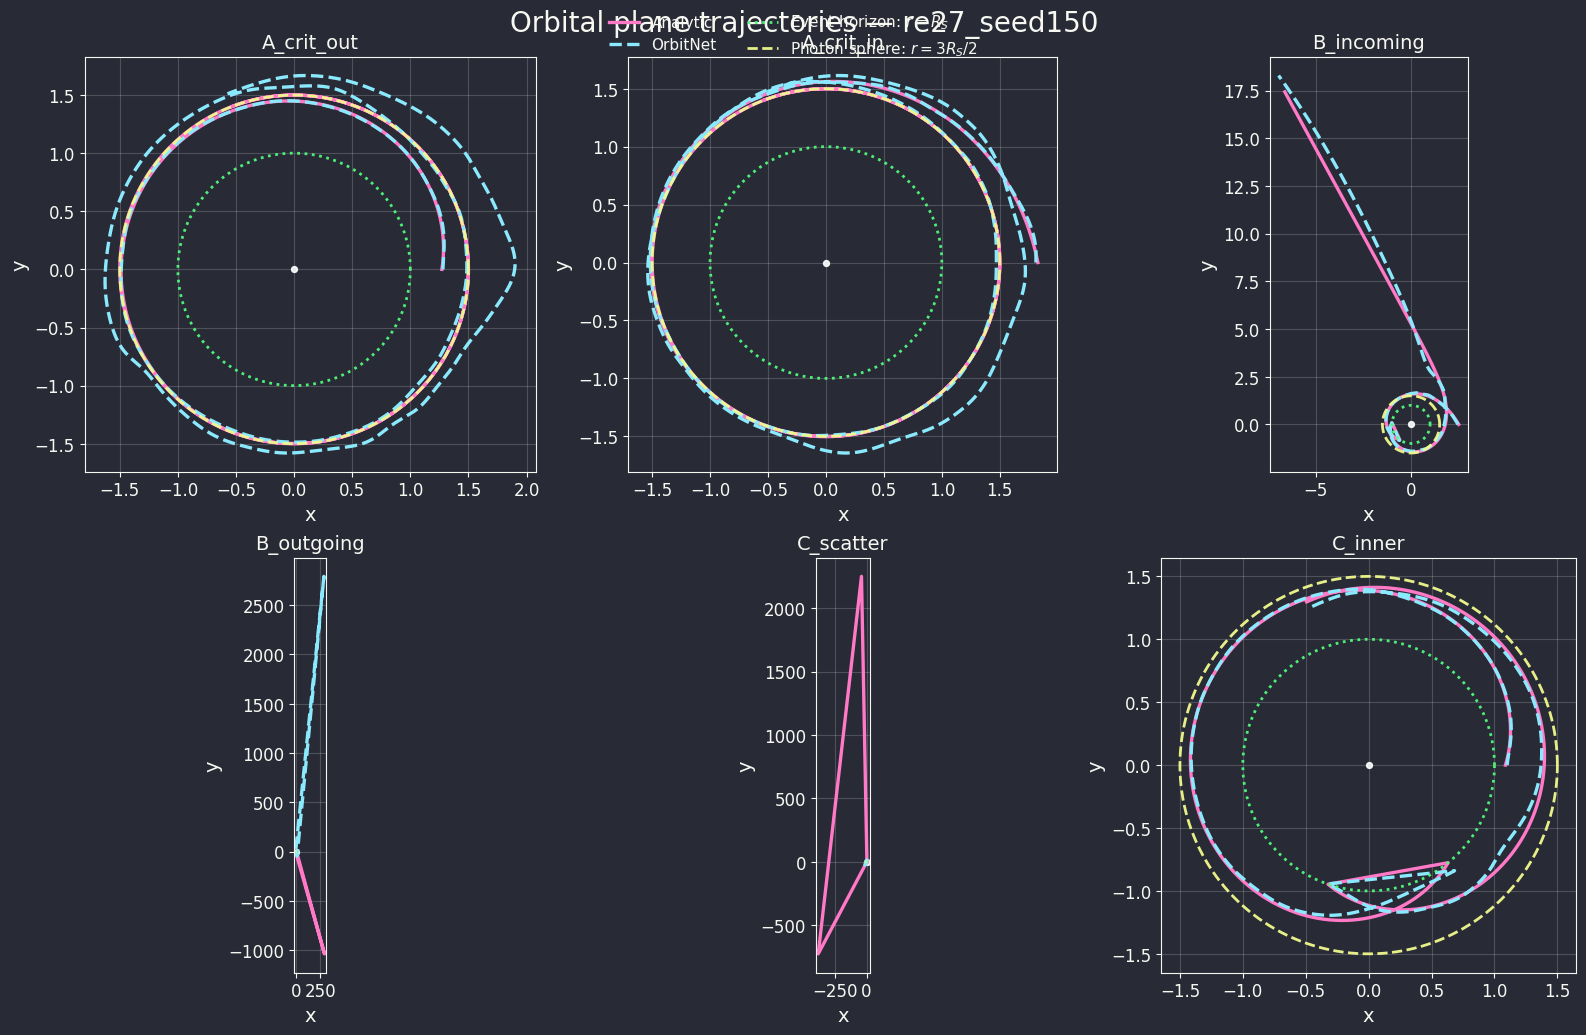

Saved: /home/kingsman/Escritorio/PhD/PINN_paper/best_orbinet/out/deflection_benchmark/figs/orbit_xy_grid_re27_seed150.png


In [47]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10), constrained_layout=True)
axes = axes.ravel()

for i, (name, b, u0, kwargs) in enumerate(cases):
    u_true, _ = u_phi_general(phi, Rs=Rs, b=b, u0=u0, phi0=0.0, **kwargs)
    u_hat = predict_u(
        model, phi, u0, b, Rs=Rs, K=K,
        add_valid_flag=ADD_VALID_FLAG,
        target_transform=TARGET_TF
    )

    m = np.isfinite(u_true) & (u_true > 0) & np.isfinite(u_hat) & (u_hat > 0)
    xT, yT, _ = orbit_xy(phi[m], u_true[m], Rs=Rs)
    xP, yP, _ = orbit_xy(phi[m], u_hat[m], Rs=Rs)

    ax = axes[i]
    ax.plot(xT, yT, color=C_ANALYTIC, label="Analytic")
    ax.plot(xP, yP, "--", color=C_MODEL, label="OrbitNet")
    draw_reference(ax, Rs=Rs)
    ax.set_title(name)
    ax.set_xlabel("x")
    ax.set_ylabel("y")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False)
fig.suptitle(f"Orbital plane trajectories — {exp_id}", y=1.02)

out = os.path.join(OUT_FIGS, f"orbit_xy_grid_{exp_id}.png")
fig.savefig(out, dpi=220, bbox_inches="tight")
plt.show()

print("Saved:", out)

## Error as a function of angle

We inspect the mean absolute error in $u(\phi)$ as a function of $\phi$ for each representative case.

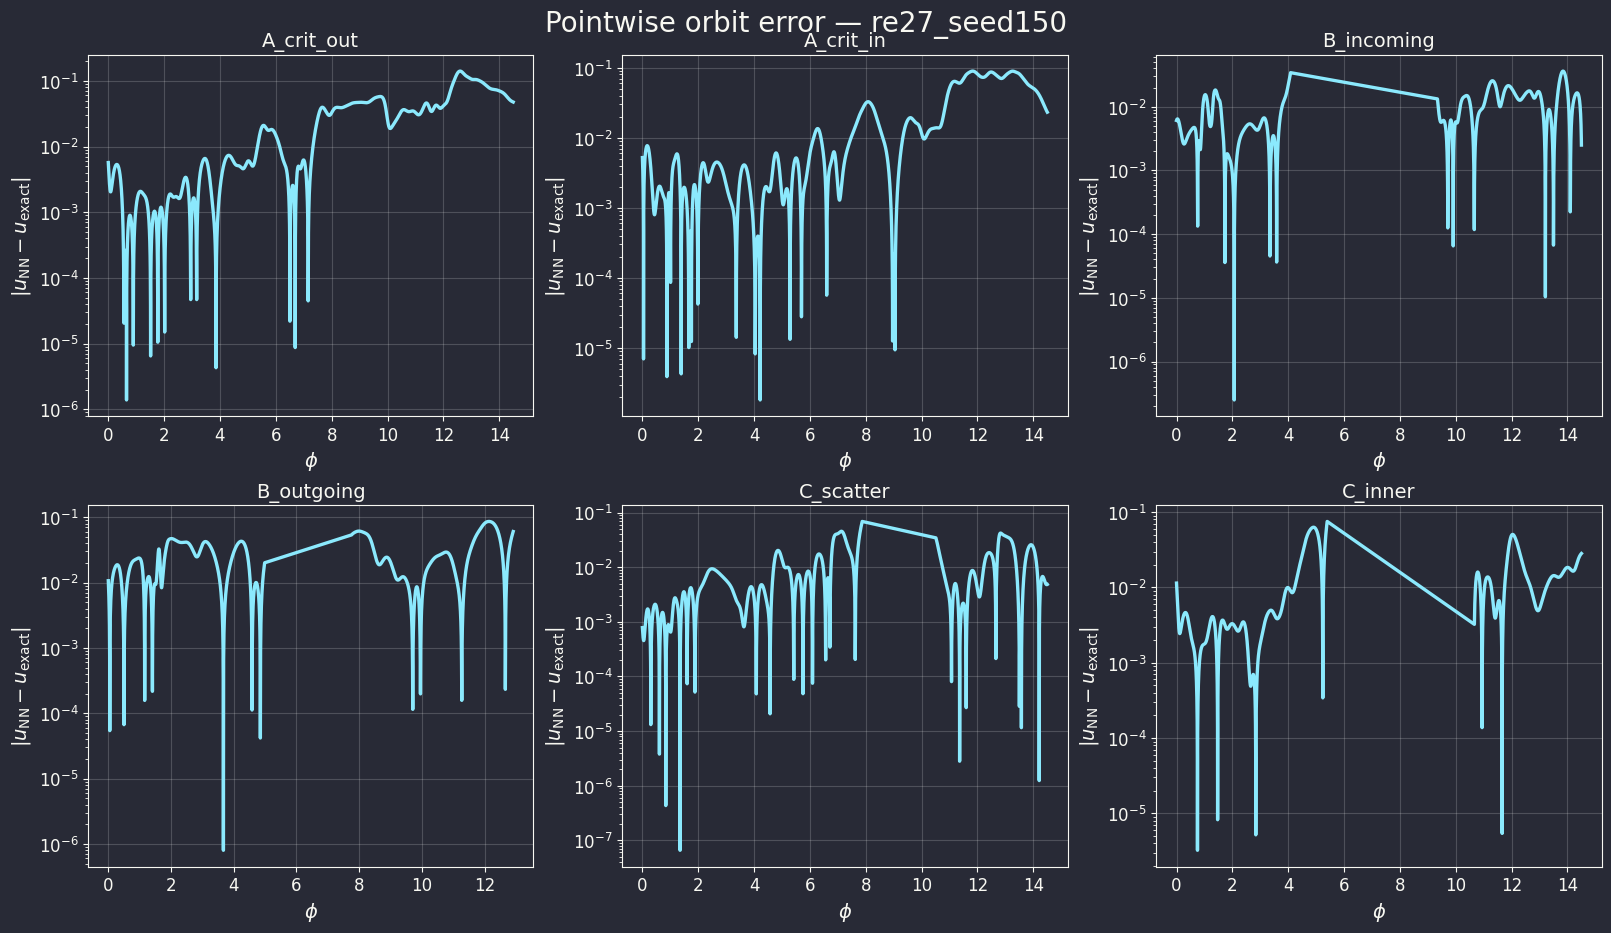

Saved: /home/kingsman/Escritorio/PhD/PINN_paper/best_orbinet/out/deflection_benchmark/figs/u_error_vs_phi_re27_seed150.png


In [48]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9), constrained_layout=True)
axes = axes.ravel()

for i, (name, b, u0, kwargs) in enumerate(cases):
    u_true, _ = u_phi_general(phi, Rs=Rs, b=b, u0=u0, phi0=0.0, **kwargs)
    u_hat = predict_u(
        model, phi, u0, b, Rs=Rs, K=K,
        add_valid_flag=ADD_VALID_FLAG,
        target_transform=TARGET_TF
    )

    m = np.isfinite(u_true) & (u_true > 0) & np.isfinite(u_hat) & (u_hat > 0)
    err = np.abs(u_hat[m] - u_true[m])

    ax = axes[i]
    ax.plot(phi[m], err)
    ax.set_yscale("log")
    ax.set_title(name)
    ax.set_xlabel(r"$\phi$")
    ax.set_ylabel(r"$|u_{\rm NN}-u_{\rm exact}|$")
    ax.grid(True, alpha=0.18, color=C_GRID)

fig.suptitle(f"Pointwise orbit error — {exp_id}", y=1.02)

out = os.path.join(OUT_FIGS, f"u_error_vs_phi_{exp_id}.png")
fig.savefig(out, dpi=220, bbox_inches="tight")
plt.show()

print("Saved:", out)

## Learning curves

Training and validation histories from the selected retrained checkpoint.

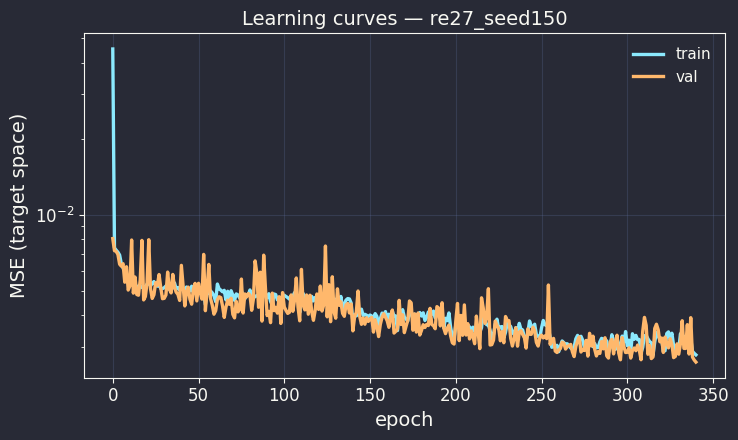

Saved: /home/kingsman/Escritorio/PhD/PINN_paper/best_orbinet/out/deflection_benchmark/figs/curve_trainval_re27_seed150.png


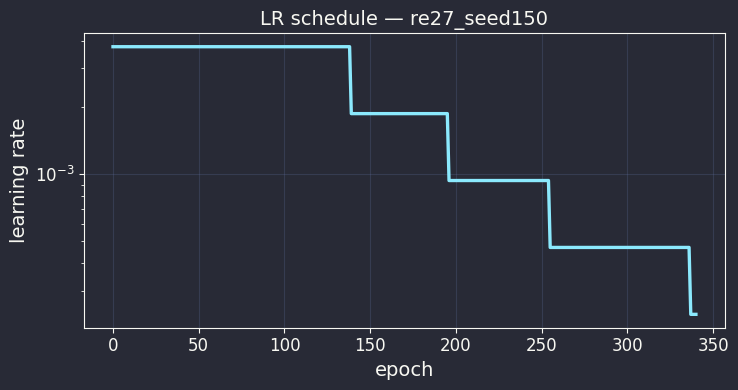

Saved: /home/kingsman/Escritorio/PhD/PINN_paper/best_orbinet/out/deflection_benchmark/figs/curve_lr_re27_seed150.png


In [49]:
tr = ckpt["train_hist"]
va = ckpt["val_hist"]
lr = ckpt["lr_hist"]

plt.figure(figsize=(7.5, 4.5))
plt.plot(tr, label="train")
plt.plot(va, label="val")
plt.yscale("log")
plt.xlabel("epoch")
plt.ylabel("MSE (target space)")
plt.title(f"Learning curves — {exp_id}")
plt.grid(True, alpha=0.25)
plt.legend()
out = os.path.join(OUT_FIGS, f"curve_trainval_{exp_id}.png")
plt.tight_layout()
plt.savefig(out, dpi=200)
plt.show()

print("Saved:", out)

plt.figure(figsize=(7.5, 4.0))
plt.plot(lr)
plt.yscale("log")
plt.xlabel("epoch")
plt.ylabel("learning rate")
plt.title(f"LR schedule — {exp_id}")
plt.grid(True, alpha=0.25)
out = os.path.join(OUT_FIGS, f"curve_lr_{exp_id}.png")
plt.tight_layout()
plt.savefig(out, dpi=200)
plt.show()

print("Saved:", out)

## Hero scattering case: exact orbit, emulated orbit, and deflection-angle estimate

We now focus on a scattering trajectory, because the deflection angle is physically defined for orbits that come from infinity and return to infinity.

In [98]:
hero_name = "C_scatter"
#hero_b = 1.004 * bc
hero_b = 1.005 * bc
hero_u0 = 0.15
hero_kwargs = dict(branch=None, region="scatter")

u_true, _ = u_phi_general(phi, Rs=Rs, b=hero_b, u0=hero_u0, phi0=0.0, **hero_kwargs)
u_hat = predict_u(
    model, phi, hero_u0, hero_b, Rs=Rs, K=K,
    add_valid_flag=ADD_VALID_FLAG,
    target_transform=TARGET_TF
)

alpha_exact, aux = deflection_exact_eq56(Rs, hero_b)
alpha_nn = estimate_deflection_from_u(phi, u_hat, u_eps=1e-3)
alpha_true_num = estimate_deflection_from_u(phi, u_true, u_eps=1e-3)

print("Hero case:", hero_name)
print("b/bc =", hero_b / bc)
print("delta_phi exact paper =", alpha_exact)
print("delta_phi analytic-orbit numerical =", alpha_true_num)
print("delta_phi NN-orbit numerical =", alpha_nn)
print("abs error NN vs exact =", abs(alpha_nn - alpha_exact))

Hero case: C_scatter
b/bc = 1.005
delta_phi exact paper = 4.9114312185858555
delta_phi analytic-orbit numerical = nan
delta_phi NN-orbit numerical = nan
abs error NN vs exact = nan


In [102]:
#celda para cambiar el rango provisionalmente para ver las curvas
phi_max = 11.2
nphi = 4000
phi = np.linspace(1e-4, phi_max, nphi).astype(np.float32)


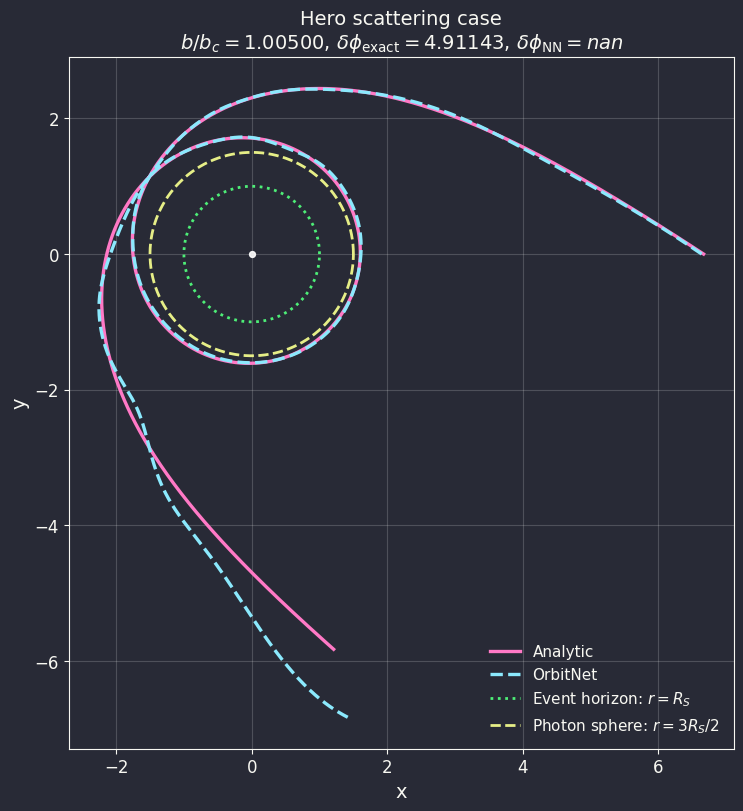

Saved: /home/kingsman/Escritorio/PhD/PINN_paper/best_orbinet/out/deflection_benchmark/figs/hero_scatter_re27_seed150.png


In [103]:
m = np.isfinite(u_true) & (u_true > 0) & np.isfinite(u_hat) & (u_hat > 0)
xT, yT, _ = orbit_xy(phi[m], u_true[m], Rs=Rs)
xP, yP, _ = orbit_xy(phi[m], u_hat[m], Rs=Rs)

fig, ax = plt.subplots(figsize=(8, 8), constrained_layout=True)
ax.plot(xT, yT, color=C_ANALYTIC, label="Analytic")
ax.plot(xP, yP, "--", color=C_MODEL, label="OrbitNet")
draw_reference(ax, Rs=Rs)
ax.set_title(
    "Hero scattering case\n"
    + rf"$b/b_c={hero_b/bc:.5f}$, "
    + rf"$\delta\phi_{{\rm exact}}={alpha_exact:.5f}$, "
    + rf"$\delta\phi_{{\rm NN}}={alpha_nn:.5f}$"
)
ax.set_xlabel("x")
ax.set_ylabel("y")
# ax.set_xscale("log")
# ax.set_yscale("log")
ax.legend(frameon=False)

out = os.path.join(OUT_FIGS, f"hero_scatter_{exp_id}.png")
fig.savefig(out, dpi=240, bbox_inches="tight")
plt.show()

print("Saved:", out)

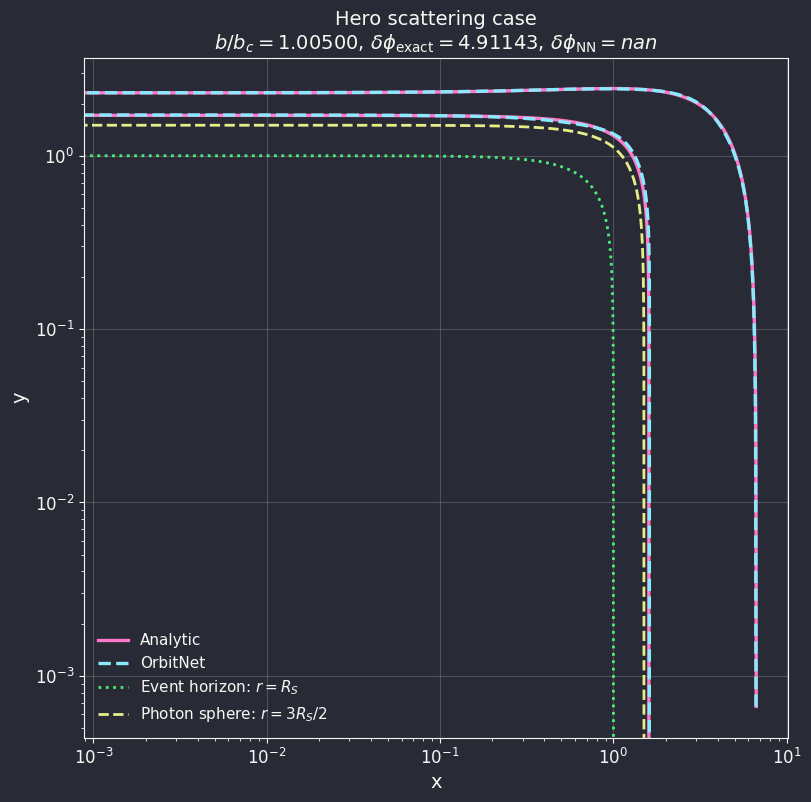

Saved: /home/kingsman/Escritorio/PhD/PINN_paper/best_orbinet/out/deflection_benchmark/figs/hero_scatter_re27_seed150.png


In [104]:
m = np.isfinite(u_true) & (u_true > 0) & np.isfinite(u_hat) & (u_hat > 0)
xT, yT, _ = orbit_xy(phi[m], u_true[m], Rs=Rs)
xP, yP, _ = orbit_xy(phi[m], u_hat[m], Rs=Rs)

fig, ax = plt.subplots(figsize=(8, 8), constrained_layout=True)
ax.plot(xT, yT, color=C_ANALYTIC, label="Analytic")
ax.plot(xP, yP, "--", color=C_MODEL, label="OrbitNet")
draw_reference(ax, Rs=Rs)
ax.set_title(
    "Hero scattering case\n"
    + rf"$b/b_c={hero_b/bc:.5f}$, "
    + rf"$\delta\phi_{{\rm exact}}={alpha_exact:.5f}$, "
    + rf"$\delta\phi_{{\rm NN}}={alpha_nn:.5f}$"
)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_xscale("log")
ax.set_yscale("log")    
ax.legend(frameon=False)

out = os.path.join(OUT_FIGS, f"hero_scatter_{exp_id}.png")
fig.savefig(out, dpi=240, bbox_inches="tight")
plt.show()

print("Saved:", out)

## Deflection-angle benchmark over impact parameter

We sweep over scattering impact parameters $b>b_{\rm crit}$, compute:
- the exact deflection angle from Eq. (56),
- the OrbitNet-based estimate from the emulated orbit,
- and timing information.

This is the main observable benchmark.

In [22]:
# You can change the grid depending on how close to criticality you want to go.
b_grid = np.linspace(1.01*bc, 1.20*bc, 80)
u0_benchmark = 0.15
u_eps = 1e-3

rows = []

for b in b_grid:
    kwargs = dict(branch=None, region="scatter")

    # exact paper formula
    delta_exact, aux = deflection_exact_eq56(Rs, b)

    # analytic orbit from your solver
    try:
        u_true, _ = u_phi_general(phi, Rs=Rs, b=b, u0=u0_benchmark, phi0=0.0, **kwargs)
    except Exception:
        rows.append({
            "b": b,
            "b_over_bc": b / bc,
            "delta_exact": delta_exact,
            "delta_true_num": np.nan,
            "delta_nn": np.nan,
            "abs_err_nn_vs_exact": np.nan,
            "rel_err_nn_vs_exact": np.nan,
            "nn_time_ms": np.nan,
        })
        continue

    # NN inference
    t0 = time.perf_counter()
    u_hat = predict_u(
        model, phi, u0_benchmark, b, Rs=Rs, K=K,
        add_valid_flag=ADD_VALID_FLAG,
        target_transform=TARGET_TF
    )
    t1 = time.perf_counter()

    delta_true_num = estimate_deflection_from_u(phi, u_true, u_eps=u_eps)
    delta_nn = estimate_deflection_from_u(phi, u_hat, u_eps=u_eps)

    abs_err = np.nan
    rel_err = np.nan
    if np.isfinite(delta_exact) and np.isfinite(delta_nn):
        abs_err = abs(delta_nn - delta_exact)
        if abs(delta_exact) > 0:
            rel_err = abs_err / abs(delta_exact)

    rows.append({
        "b": b,
        "b_over_bc": b / bc,
        "delta_exact": delta_exact,
        "delta_true_num": delta_true_num,
        "delta_nn": delta_nn,
        "abs_err_nn_vs_exact": abs_err,
        "rel_err_nn_vs_exact": rel_err,
        "nn_time_ms": 1e3 * (t1 - t0),
    })

defl_df = pd.DataFrame(rows)
display(defl_df.head())

csv_path = os.path.join(OUT_TAB, f"deflection_benchmark_{exp_id}.csv")
defl_df.to_csv(csv_path, index=False)
print("Saved:", csv_path)

,b,b_over_bc,delta_exact,delta_true_num,delta_nn,abs_err_nn_vs_exact,rel_err_nn_vs_exact,nn_time_ms
0,2.624057,1.010000,4.229662,NaN,NaN,NaN,NaN,158.158161
1,2.630306,1.012405,4.019323,NaN,NaN,NaN,NaN,85.340283
2,2.636554,1.014810,3.847158,NaN,NaN,NaN,NaN,50.083912
3,2.642803,1.017215,3.701603,NaN,NaN,NaN,NaN,68.534151
4,2.649051,1.019620,3.575657,NaN,NaN,NaN,NaN,112.471820


Saved: /home/kingsman/Escritorio/PhD/PINN_paper/best_orbinet/out/deflection_benchmark/tables/deflection_benchmark_re27_seed150.csv


## Main result: deflection angle vs impact parameter

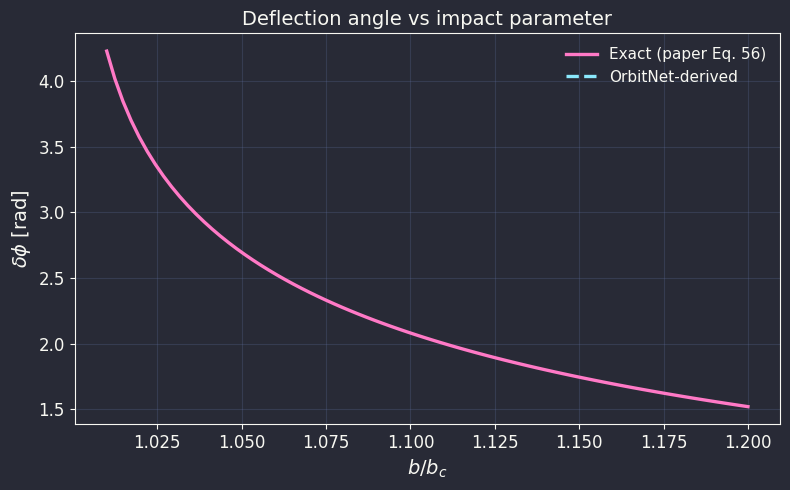

Saved: /home/kingsman/Escritorio/PhD/PINN_paper/best_orbinet/out/deflection_benchmark/figs/deflection_vs_b_re27_seed150.png


In [25]:
plt.figure(figsize=(8, 5))
plt.plot(defl_df["b_over_bc"], defl_df["delta_exact"], color=C_EXACT, label="Exact (paper Eq. 56)")
plt.plot(defl_df["b_over_bc"], defl_df["delta_nn"], "--", color=C_NN, label="OrbitNet-derived")
plt.xlabel(r"$b/b_c$")
plt.ylabel(r"$\delta\phi$ [rad]")
plt.title("Deflection angle vs impact parameter")
plt.grid(True, alpha=0.25)
plt.legend()
out = os.path.join(OUT_FIGS, f"deflection_vs_b_{exp_id}.png")
plt.tight_layout()
plt.savefig(out, dpi=220)
plt.show()

print("Saved:", out)

## Absolute and relative error in deflection angle

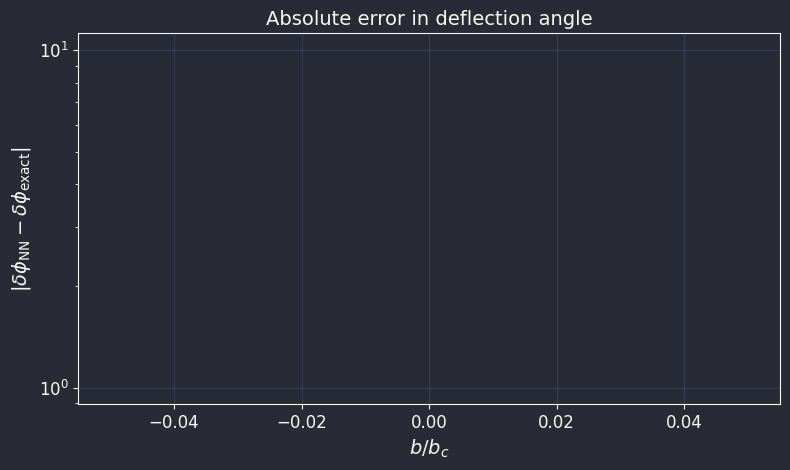

Saved: /home/kingsman/Escritorio/PhD/PINN_paper/best_orbinet/out/deflection_benchmark/figs/deflection_abs_error_re27_seed150.png


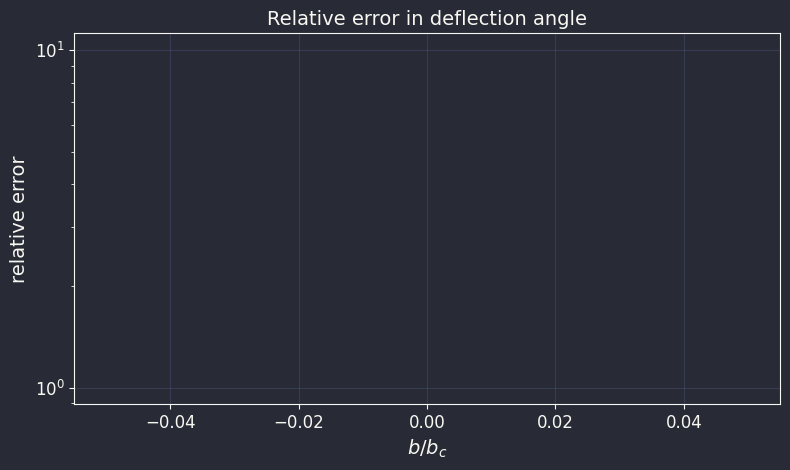

Saved: /home/kingsman/Escritorio/PhD/PINN_paper/best_orbinet/out/deflection_benchmark/figs/deflection_rel_error_re27_seed150.png


In [26]:
plt.figure(figsize=(8, 4.8))
plt.plot(defl_df["b_over_bc"], defl_df["abs_err_nn_vs_exact"])
plt.yscale("log")
plt.xlabel(r"$b/b_c$")
plt.ylabel(r"$|\delta\phi_{\rm NN}-\delta\phi_{\rm exact}|$")
plt.title("Absolute error in deflection angle")
plt.grid(True, alpha=0.25)
out = os.path.join(OUT_FIGS, f"deflection_abs_error_{exp_id}.png")
plt.tight_layout()
plt.savefig(out, dpi=220)
plt.show()

print("Saved:", out)

plt.figure(figsize=(8, 4.8))
plt.plot(defl_df["b_over_bc"], defl_df["rel_err_nn_vs_exact"])
plt.yscale("log")
plt.xlabel(r"$b/b_c$")
plt.ylabel("relative error")
plt.title("Relative error in deflection angle")
plt.grid(True, alpha=0.25)
out = os.path.join(OUT_FIGS, f"deflection_rel_error_{exp_id}.png")
plt.tight_layout()
plt.savefig(out, dpi=220)
plt.show()

print("Saved:", out)

## Compare exact solution with weak-field and strong-field approximations

This is useful as a physics sanity check:
- weak-field approximation should work better at large $b$,
- strong-field approximation should improve near $b_{\rm crit}$.

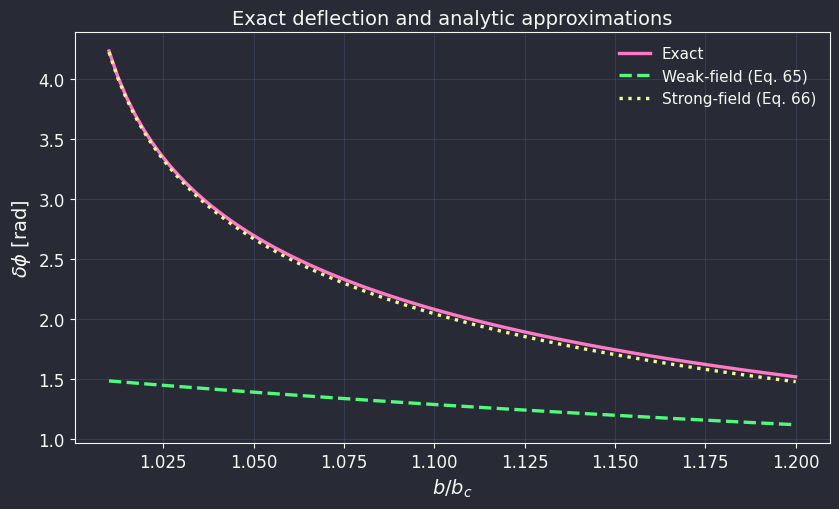

Saved: /home/kingsman/Escritorio/PhD/PINN_paper/best_orbinet/out/deflection_benchmark/figs/deflection_exact_vs_approximations_re27_seed150.png


In [27]:
defl_df["delta_weak"] = defl_df["b"].apply(lambda bb: deflection_weak_eq65(Rs, bb))
defl_df["delta_strong"] = defl_df["b"].apply(lambda bb: deflection_strong_eq66(Rs, bb))

plt.figure(figsize=(8.5, 5.2))
plt.plot(defl_df["b_over_bc"], defl_df["delta_exact"], color=C_EXACT, label="Exact")
plt.plot(defl_df["b_over_bc"], defl_df["delta_weak"], color=C_WEAK, ls="--", label="Weak-field (Eq. 65)")
plt.plot(defl_df["b_over_bc"], defl_df["delta_strong"], color=C_STRONG, ls=":", label="Strong-field (Eq. 66)")
plt.xlabel(r"$b/b_c$")
plt.ylabel(r"$\delta\phi$ [rad]")
plt.title("Exact deflection and analytic approximations")
plt.grid(True, alpha=0.25)
plt.legend()
out = os.path.join(OUT_FIGS, f"deflection_exact_vs_approximations_{exp_id}.png")
plt.tight_layout()
plt.savefig(out, dpi=220)
plt.show()

print("Saved:", out)

## Zoom near the critical impact parameter

This region is especially important because the deflection grows rapidly as $b \to b_{\rm crit}^{+}$.

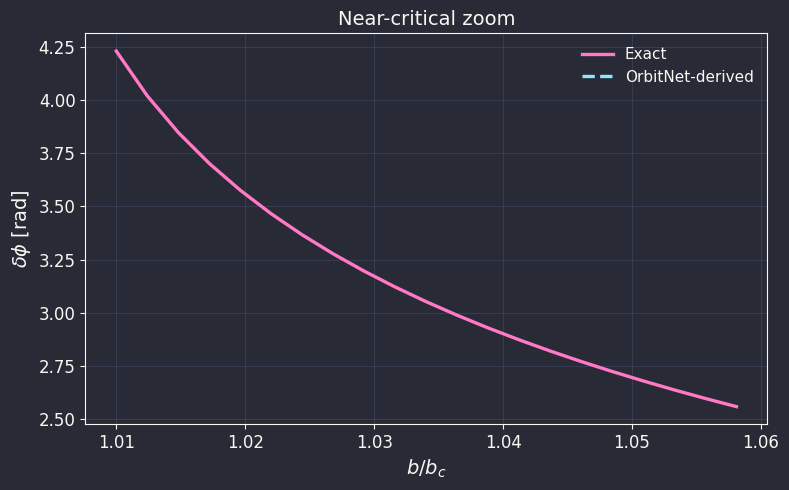

Saved: /home/kingsman/Escritorio/PhD/PINN_paper/best_orbinet/out/deflection_benchmark/figs/deflection_near_critical_re27_seed150.png


In [28]:
mask_zoom = defl_df["b_over_bc"] <= 1.06

plt.figure(figsize=(8, 5))
plt.plot(defl_df.loc[mask_zoom, "b_over_bc"], defl_df.loc[mask_zoom, "delta_exact"],
         color=C_EXACT, label="Exact")
plt.plot(defl_df.loc[mask_zoom, "b_over_bc"], defl_df.loc[mask_zoom, "delta_nn"],
         "--", color=C_NN, label="OrbitNet-derived")
plt.xlabel(r"$b/b_c$")
plt.ylabel(r"$\delta\phi$ [rad]")
plt.title("Near-critical zoom")
plt.grid(True, alpha=0.25)
plt.legend()
out = os.path.join(OUT_FIGS, f"deflection_near_critical_{exp_id}.png")
plt.tight_layout()
plt.savefig(out, dpi=220)
plt.show()

print("Saved:", out)

## Timing benchmark

Inference speed for the OrbitNet-based deflection-angle evaluation over the benchmark grid.

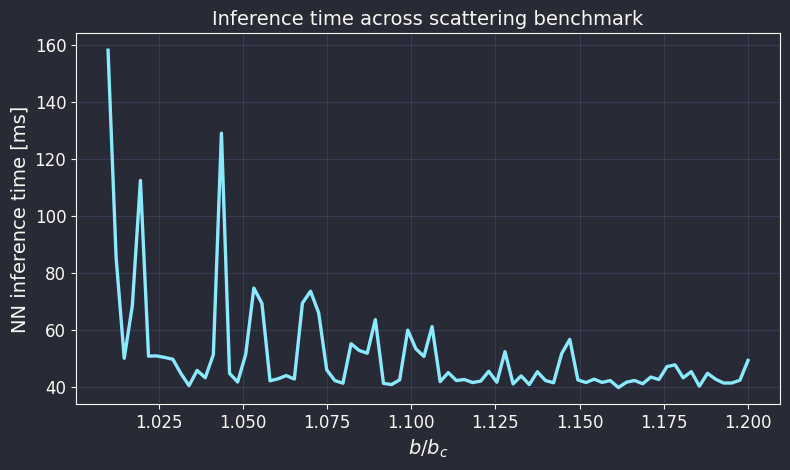

Saved: /home/kingsman/Escritorio/PhD/PINN_paper/best_orbinet/out/deflection_benchmark/figs/deflection_timing_re27_seed150.png


In [29]:
plt.figure(figsize=(8, 4.8))
plt.plot(defl_df["b_over_bc"], defl_df["nn_time_ms"])
plt.xlabel(r"$b/b_c$")
plt.ylabel("NN inference time [ms]")
plt.title("Inference time across scattering benchmark")
plt.grid(True, alpha=0.25)
out = os.path.join(OUT_FIGS, f"deflection_timing_{exp_id}.png")
plt.tight_layout()
plt.savefig(out, dpi=220)
plt.show()

print("Saved:", out)

## Summary metrics

In [30]:
summary = {
    "exp_id": exp_id,
    "seed": int(best["seed"]) if "seed" in best else None,
    "mode": str(best["mode"]),
    "target_transform": TARGET_TF,
    "add_valid_flag": int(ADD_VALID_FLAG),
    "K": K,
    "width": int(best["width"]),
    "depth": int(best["depth"]),
    "lambda_pinn": float(best["lambda_pinn"]),
    "best_val": float(best["best_val"]),
    "test_mse": float(best["test_mse"]),
    "deflection_n_valid": int(defl_df["abs_err_nn_vs_exact"].notna().sum()),
    "deflection_mean_abs_err": float(defl_df["abs_err_nn_vs_exact"].mean()),
    "deflection_std_abs_err": float(defl_df["abs_err_nn_vs_exact"].std()),
    "deflection_median_abs_err": float(defl_df["abs_err_nn_vs_exact"].median()),
    "deflection_mean_rel_err": float(defl_df["rel_err_nn_vs_exact"].mean()),
    "deflection_std_rel_err": float(defl_df["rel_err_nn_vs_exact"].std()),
    "mean_nn_time_ms": float(defl_df["nn_time_ms"].mean()),
}

summary_df = pd.DataFrame([summary])
display(summary_df)

csv_path = os.path.join(OUT_TAB, f"summary_{exp_id}.csv")
summary_df.to_csv(csv_path, index=False)
print("Saved:", csv_path)

/home/kingsman/.local/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


,exp_id,seed,mode,target_transform,add_valid_flag,K,width,depth,lambda_pinn,best_val,test_mse,deflection_n_valid,deflection_mean_abs_err,deflection_std_abs_err,deflection_median_abs_err,deflection_mean_rel_err,deflection_std_rel_err,mean_nn_time_ms
0,re27_seed150,150,filled,log1p,1,8,320,5,0.000001,0.002608,0.002598,0,NaN,NaN,NaN,NaN,NaN,51.291841


Saved: /home/kingsman/Escritorio/PhD/PINN_paper/best_orbinet/out/deflection_benchmark/tables/summary_re27_seed150.csv


## Optional robustness test: dependence on the asymptotic cutoff $u_\varepsilon$

Because the deflection angle extracted from the orbit uses a finite threshold $u_\varepsilon$, it is useful to test whether the result is stable under small changes in that cutoff.

,u_eps,b_over_bc,delta_exact,delta_nn,abs_err
0,0.01,1.020000,3.557240,NaN,NaN
1,0.01,1.024483,3.363741,NaN,NaN
2,0.01,1.028966,3.204088,NaN,NaN
3,0.01,1.033448,3.068462,NaN,NaN
4,0.01,1.037931,2.950771,NaN,NaN


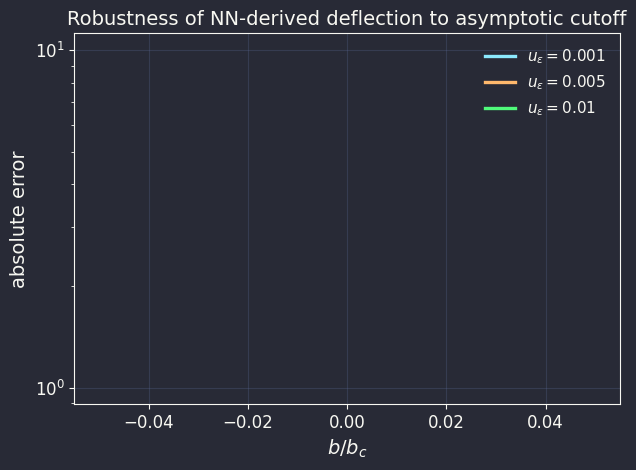

Saved: /home/kingsman/Escritorio/PhD/PINN_paper/best_orbinet/out/deflection_benchmark/figs/deflection_robustness_u_eps_re27_seed150.png
Saved: /home/kingsman/Escritorio/PhD/PINN_paper/best_orbinet/out/deflection_benchmark/tables/robustness_u_eps_re27_seed150.csv


In [31]:
u_eps_list = [1e-2, 5e-3, 1e-3]
b_probe = np.linspace(1.02*bc, 1.15*bc, 30)

robust_rows = []

for u_eps_probe in u_eps_list:
    for b in b_probe:
        kwargs = dict(branch=None, region="scatter")
        try:
            u_true, _ = u_phi_general(phi, Rs=Rs, b=b, u0=u0_benchmark, phi0=0.0, **kwargs)
            u_hat = predict_u(
                model, phi, u0_benchmark, b, Rs=Rs, K=K,
                add_valid_flag=ADD_VALID_FLAG,
                target_transform=TARGET_TF
            )
        except Exception:
            continue

        delta_exact, _ = deflection_exact_eq56(Rs, b)
        delta_nn = estimate_deflection_from_u(phi, u_hat, u_eps=u_eps_probe)

        robust_rows.append({
            "u_eps": u_eps_probe,
            "b_over_bc": b/bc,
            "delta_exact": delta_exact,
            "delta_nn": delta_nn,
            "abs_err": abs(delta_nn - delta_exact) if np.isfinite(delta_exact) and np.isfinite(delta_nn) else np.nan,
        })

robust_df = pd.DataFrame(robust_rows)
display(robust_df.head())

for ueps, sub in robust_df.groupby("u_eps"):
    plt.plot(sub["b_over_bc"], sub["abs_err"], label=rf"$u_\epsilon={ueps}$")

plt.yscale("log")
plt.xlabel(r"$b/b_c$")
plt.ylabel("absolute error")
plt.title("Robustness of NN-derived deflection to asymptotic cutoff")
plt.grid(True, alpha=0.25)
plt.legend()
out = os.path.join(OUT_FIGS, f"deflection_robustness_u_eps_{exp_id}.png")
plt.tight_layout()
plt.savefig(out, dpi=220)
plt.show()

print("Saved:", out)

csv_path = os.path.join(OUT_TAB, f"robustness_u_eps_{exp_id}.csv")
robust_df.to_csv(csv_path, index=False)
print("Saved:", csv_path)

## Final remarks

This notebook validates OrbitNet at three levels:

1. **Local solution accuracy** in $u(\phi)$,
2. **Geometric orbital accuracy** in the $x$-$y$ plane,
3. **Observable-level accuracy** through the deflection angle.

The deflection-angle benchmark is especially important because it connects the emulator directly with a physically meaningful lensing observable.